# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Koh Tim Yi



Student Name: Koh Tim Yi
Metric Number: 2503677C

**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [22]:
## Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import time, pickle
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Business Understanding
Goal: HDB resale flat prices in Singapore vary widely depending on location, flat type, size, and lease remaining, which makes it difficult for buyers, sellers, and agents to judge whether an asking price is fair. The goal of this model is  to build a machine learning model that predicts the resale price of an HDB flat based on its characteristics such as town, flat type, floor area, storey range, flat model, lease commencement date, and remaining lease.A reliable pricing estimate tool would help sellers set realistic asking prices, help buyers identify over or underpriced listings, and help agents justify valuations to their clients, ultimately reducing time doing reserch and negotiation friction.


# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
print(df.shape)
df.head()


(236609, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236609 entries, 0 to 236608
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                236609 non-null  object 
 1   town                 236609 non-null  object 
 2   flat_type            236609 non-null  object 
 3   block                236609 non-null  object 
 4   street_name          236609 non-null  object 
 5   storey_range         236609 non-null  object 
 6   floor_area_sqm       236609 non-null  float64
 7   flat_model           236609 non-null  object 
 8   lease_commence_date  236609 non-null  int64  
 9   remaining_lease      236609 non-null  object 
 10  resale_price         236609 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.9+ MB


df.info() prints out the summary of the DataFrame's structure such as the total row count and for each column its name,how many non-null value it has and its data type. After running, we see that there are no missing data anywhere. It also showed remaining_lease as object while floor_area_sqm and resale_price are float64  and lease_commence_date is int64 . This matters because scikit-learn models can't consume text directly and any object column either needs to be encoded into numbers (like town, flat_type, flat_model via one-hot encoding) or parsed into a numeric value (like remaining_lease, which is a string such as "61 years 04 months" that needs to become a number,eg. total months or years, before a model can use it).

In [5]:
## Check for missing data
df.isnull().sum()


month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

df.isnull().sum() is a standard command used to check whether any data is missing from your dataset. Firstly,df.isnull() scans every cell in your table and if a cell has data, it gets labeled as False, and if a cell is empty, it gets labeled as True. Then, .sum() adds those numbers up for each column, giving you a final count of missing values. Even though df.info() already showed that every single row has complete data—meaning this check will simply output zeros for every column. This just helps to verify that there are 0 missing data from the dataset.

In [6]:
## Describe data distribution
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,236609,115,2024-07,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
town,236609,26,SENGKANG,19183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,236609,7,4 ROOM,100489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,236609,2773,2,712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,236609,578,YISHUN RING RD,3343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storey_range,236609,17,04 TO 06,54249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,236609.0,NaN,NaN,NaN,96.685218,24.017699,31.0,81.0,93.0,112.0,366.7
flat_model,236609,21,Model A,85174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lease_commence_date,236609.0,NaN,NaN,NaN,1996.58095,14.373906,1966.0,1985.0,1997.0,2012.0,2022.0
remaining_lease,236609,701,94 years 10 months,1928,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Running `df.describe(include="all").T` generates a comprehensive summary of your entire dataset by combining math statistics for numerical columns with categorical metrics for text columns, and then transposing the resulting table for easy reading. Normally, `df.describe()` only analyzes numeric features like `resale_price` and `floor_area_sqm` by calculating their range, average, and spread, which helps you quickly spot outliers or potential data errors like zero floor areas or unrealistic prices. Adding `include="all"` forces pandas to also analyze text columns like `town` or `flat_model`, displaying their category counts (`unique`), most frequent value (`top`), and occurrence frequency (`freq`) so you know how many new columns One-Hot Encoding will eventually create. Finally, chaining `.T` at the end flips the output's rows and columns sideways, displaying all 11 features vertically down the page so you can inspect the full data health check without scrolling horizontally.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

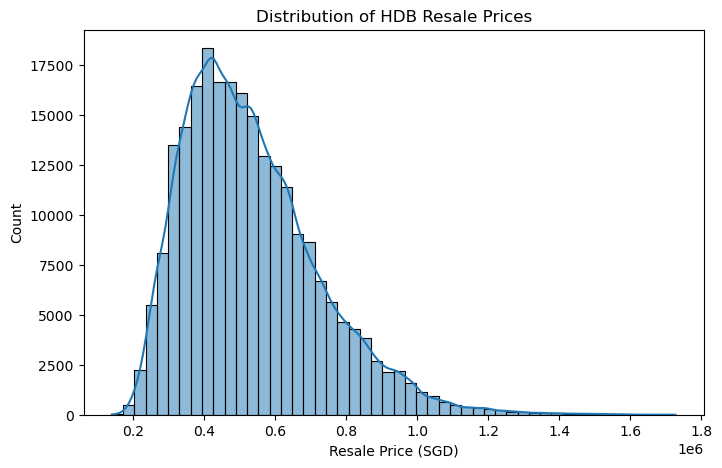

In [12]:
## Understanding distribution of target
plt.figure(figsize=(8, 5))
sns.histplot(df["resale_price"], bins=50, kde=True)
plt.title("Distribution of HDB Resale Prices")
plt.xlabel("Resale Price (SGD)")
plt.ylabel("Count")
plt.show()


Analysis of the target variable (resale_price) reveals a distinct right-skewed distribution across the dataset. Transaction values predominantly cluster within the $300,000–$650,000 range, exhibiting a clear mode between $400,000 and $450,000. A prolonged positive tail extends upward to maximum transaction values of $1.7 million.

### 2.3.1.2 Understanding distribution of features

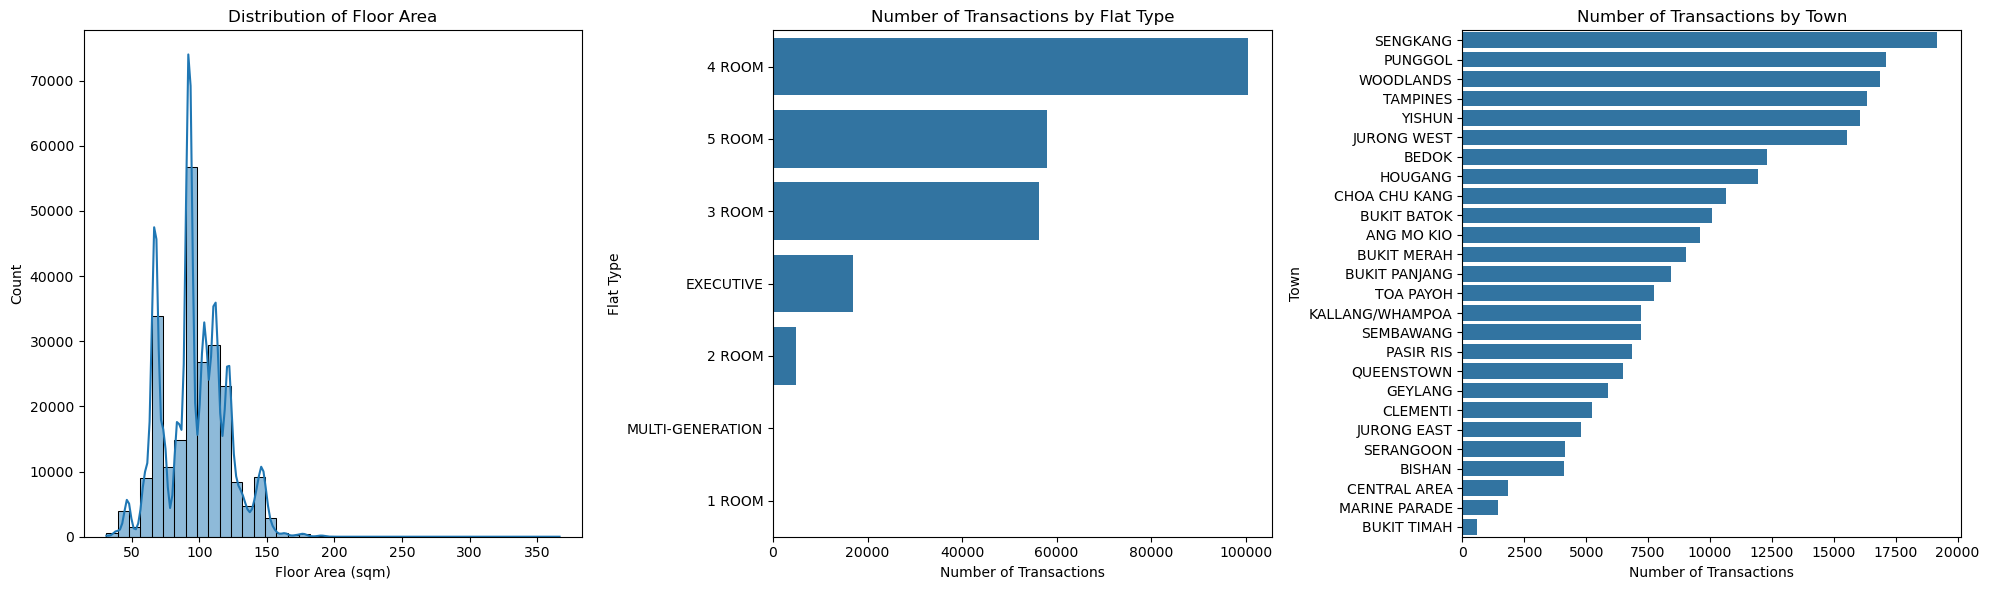

In [13]:
## Understanding distribution of features
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Numeric feature: floor area
sns.histplot(df["floor_area_sqm"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Floor Area")
axes[0].set_xlabel("Floor Area (sqm)")
axes[0].set_ylabel("Count")

# Categorical feature: flat type
sns.countplot(y=df["flat_type"], order=df["flat_type"].value_counts().index, ax=axes[1])
axes[1].set_title("Number of Transactions by Flat Type")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Flat Type")

# Categorical feature: town
sns.countplot(y=df["town"], order=df["town"].value_counts().index, ax=axes[2])
axes[2].set_title("Number of Transactions by Town")
axes[2].set_xlabel("Number of Transactions")
axes[2].set_ylabel("Town")

plt.tight_layout()
plt.show()


-My Analysis-


Floor Area (floor_area_sqm): Exhibits sharp multi-modal spikes at standard HDB dimensions (67, 92, and 93 sqm) rather than a smooth distribution, introducing significant potential multicollinearity with flat_type.

Flat Type (flat_type): Highly imbalanced toward mainstream units (4-room flats comprise 42% of 236,609 total transactions), meaning models will perform reliably on mainstream types but require uncertainty disclaimers for rare types (<100 transactions, e.g., 1-room and multi-generation).

Town (town): Distributed across all 26 towns with sufficient volume even in low-density mature estates (minimum 576 transactions in Bukit Timah), making it safe for direct one-hot encoding without prior regional grouping.

### 2.3.2 Understanding relationship between variables

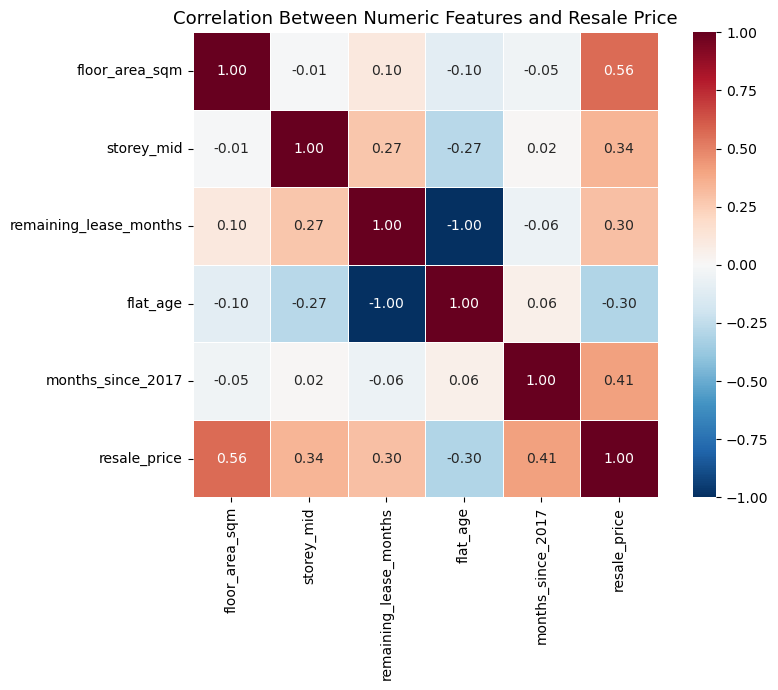

Correlation with resale_price, ranked:
floor_area_sqm            0.564377
months_since_2017         0.411395
storey_mid                0.341788
remaining_lease_months    0.301295
flat_age                 -0.300014
Name: resale_price, dtype: float64


In [15]:
## Understanding relationship between variables


eda = df.copy()

# "61 years 04 months" -> 736 months
_lease = eda["remaining_lease"].str.extract(r"^(\d+)\s+years?(?:\s+(\d+)\s+months?)?$")
eda["remaining_lease_months"] = _lease[0].astype(int) * 12 + _lease[1].fillna(0).astype(int)

# "10 TO 12" -> 11.0, the midpoint of the storey band
_storey = eda["storey_range"].str.extract(r"^(\d+)\s+TO\s+(\d+)$")
eda["storey_mid"] = (_storey[0].astype(int) + _storey[1].astype(int)) / 2

# "2017-01" -> 0, "2017-02" -> 1, ... how far into the market history the sale happened
_period = pd.PeriodIndex(eda["month"], freq="M")
eda["months_since_2017"] = (_period.year - 2017) * 12 + (_period.month - 1)

# Age of the flat at the point of sale
eda["flat_age"] = _period.year - eda["lease_commence_date"]

numeric_cols = ["floor_area_sqm", "storey_mid", "remaining_lease_months",
                "flat_age", "months_since_2017", "resale_price"]

plt.figure(figsize=(9, 7))
sns.heatmap(eda[numeric_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Between Numeric Features and Resale Price", fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation with resale_price, ranked:")
print(eda[numeric_cols].corr()["resale_price"].drop("resale_price").sort_values(ascending=False))


-My Analysis_

Looking at the correlation matrix, floor area (floor_area_sqm) is the biggest numeric factor for price at $+0.56$, which makes sense because bigger flats cost more, but since it’s only a moderate correlation, stuff like location (town) is obviously doing a lot of the heavy lifting behind the scenes. Transaction date (months_since_2017 at $+0.41$) is the second biggest driver, showing how prices shot up between 2017 and 2026, so we definitely need time-based features to get accurate current valuations instead of treating an old sale like a recent one. Higher floors also get a price bump (storey_mid at $+0.34$), which makes converting the storey ranges into numeric midpoints worth it. Lastly, flat age and remaining lease are basically exact opposites ($-0.30$ and $+0.30$) because of HDB's 99-year lease rule, so keeping both would just cause bad multicollinearity—meaning we should just drop one before training the models.


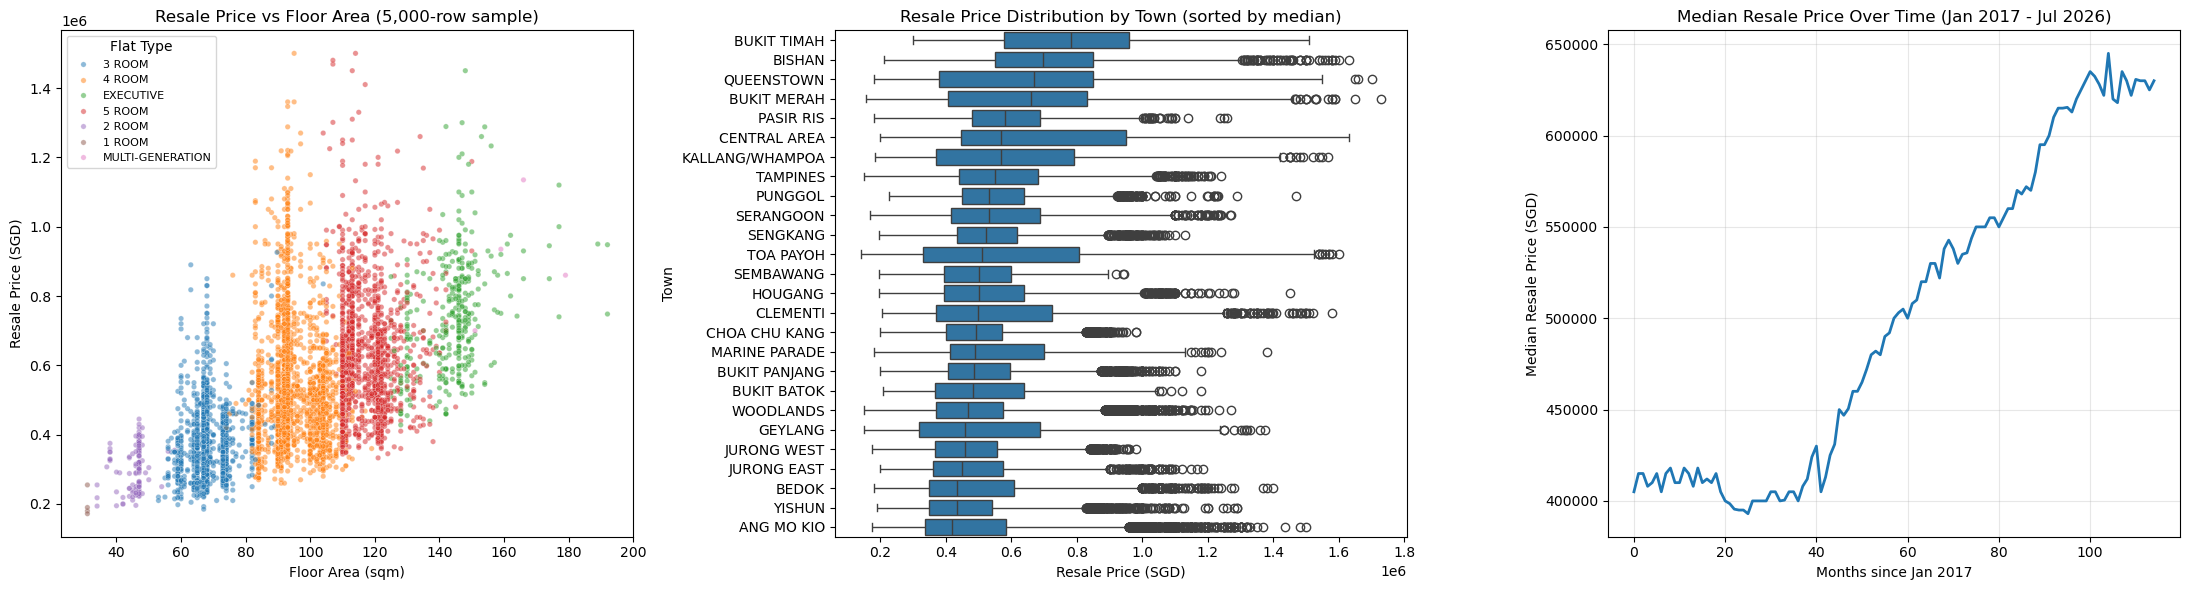

Median price by town - top 5:
town
BUKIT TIMAH    781500.0
BISHAN         696400.0
QUEENSTOWN     670000.0
BUKIT MERAH    660000.0
PASIR RIS      580000.0
Name: resale_price, dtype: float64

Median price by town - bottom 5:
town
JURONG WEST    460000.0
JURONG EAST    448000.0
BEDOK          435000.0
YISHUN         433000.0
ANG MO KIO     420000.0
Name: resale_price, dtype: float64

Most expensive town is 1.86x the cheapest.


In [16]:
## Relationship between the target and the key features
## The heatmap above could not include `town` because correlation only works on numeric
## columns. These plots test the three different KINDS of relationship in the data:
## numeric (floor area), categorical (town), and temporal (market drift).
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Does price scale with size, and does flat type explain the clustering seen earlier?
sns.scatterplot(data=eda.sample(5000, random_state=42), x="floor_area_sqm", y="resale_price",
                hue="flat_type", alpha=0.5, s=15, ax=axes[0])
axes[0].set_title("Resale Price vs Floor Area (5,000-row sample)")
axes[0].set_xlabel("Floor Area (sqm)")
axes[0].set_ylabel("Resale Price (SGD)")
axes[0].legend(title="Flat Type", fontsize=8)

# Which towns command a premium? Sorted so the ranking is readable.
town_order = eda.groupby("town")["resale_price"].median().sort_values(ascending=False).index
sns.boxplot(data=eda, y="town", x="resale_price", order=town_order, ax=axes[1])
axes[1].set_title("Resale Price Distribution by Town (sorted by median)")
axes[1].set_xlabel("Resale Price (SGD)")
axes[1].set_ylabel("Town")

# Has the market drifted over time?
monthly = eda.groupby("month")["resale_price"].median()
axes[2].plot(range(len(monthly)), monthly.values, linewidth=2)
axes[2].set_title("Median Resale Price Over Time (Jan 2017 - Jul 2026)")
axes[2].set_xlabel("Months since Jan 2017")
axes[2].set_ylabel("Median Resale Price (SGD)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

town_medians = eda.groupby("town")["resale_price"].median().sort_values(ascending=False)
print("Median price by town - top 5:"); print(town_medians.head(5))
print("\nMedian price by town - bottom 5:"); print(town_medians.tail(5))
print(f"\nMost expensive town is {town_medians.iloc[0] / town_medians.iloc[-1]:.2f}x the cheapest.")


Looking at the plots, there's a clear upward trend with floor area, but flats of the exact same size have huge price differences of several hundred thousand dollars, which proves why a simple price-per-sqm rule doesn't cut it and why we need a multi-feature model. The town boxplots show a massive location premium between top central estates and bottom ones, proving that location is doing the heavy lifting that the correlation matrix couldn't capture because it's categorical. The price over time graph stays pretty flat from 2017 to 2019 before shooting up continuously from 2020 to 2026, validating our decision to add a market-timing feature so the model doesn't treat an old sale like a modern one (though it values flats at current market rates rather than predicting the future). Finally, all those million-dollar-plus outliers up to $1.728M are genuine premium sales rather than typos, so we're keeping them in the dataset, even though those high values will end up inflating RMSE compared to MAE later on.

# 3. Data Preparation

## 3.1 Data Cleaning

In [17]:
## Clean data


print("Rows before cleaning:", f"{len(df):,}")

# --- 1. Exact duplicate rows ---
dupes = df.duplicated()
print(f"\nExact duplicate rows: {dupes.sum():,} ({dupes.mean():.2%} of the dataset)")

# --- 2. Range / validity checks on numeric columns ---
print("\nValidity checks:")
print("  Non-positive resale_price :", (df["resale_price"] <= 0).sum())
print("  Non-positive floor_area   :", (df["floor_area_sqm"] <= 0).sum())
print("  lease_commence_date range :", df["lease_commence_date"].min(), "to", df["lease_commence_date"].max())
print("  floor_area_sqm range      :", df["floor_area_sqm"].min(), "to", df["floor_area_sqm"].max())
print("  month range               :", df["month"].min(), "to", df["month"].max())

# --- 3. Category hygiene: stray whitespace or inconsistent casing would silently
#        create duplicate categories during one-hot encoding (e.g. "Model A" vs "MODEL A")
print("\nCategory hygiene:")
for col in ["town", "flat_type", "flat_model", "storey_range"]:
    raw = df[col].nunique()
    normalised = df[col].str.strip().str.upper().nunique()
    flag = "OK" if raw == normalised else "MISMATCH - needs cleaning"
    print(f"  {col:14s} unique={raw:3d}  after strip+uppercase={normalised:3d}  [{flag}]")


Rows before cleaning: 236,609

Exact duplicate rows: 316 (0.13% of the dataset)

Validity checks:
  Non-positive resale_price : 0
  Non-positive floor_area   : 0
  lease_commence_date range : 1966 to 2022
  floor_area_sqm range      : 31.0 to 366.7
  month range               : 2017-01 to 2026-07

Category hygiene:
  town           unique= 26  after strip+uppercase= 26  [OK]
  flat_type      unique=  7  after strip+uppercase=  7  [OK]
  flat_model     unique= 21  after strip+uppercase= 21  [OK]
  storey_range   unique= 17  after strip+uppercase= 17  [OK]


There are 316 duplicated rows, as there is no transaction ID, 2 different flats with identical characteristics are indistinguishable by design. My justification for dropping them would be that if the same row lands in both my training and test sets, the model is tested on a record it has already memorised. That inflates my test score. Since my entire model selection argument rests on honest test metrics, protecting that is worth more than retaining 0.13% of rows.

In [18]:
## removing the 316 exact duplicate rows 
df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"Rows before  : {len(df):,}")
print(f"Rows removed : {len(df) - len(df_clean):,}")
print(f"Rows after   : {len(df_clean):,}")
print(f"\nVerification - remaining duplicates: {df_clean.duplicated().sum()}")
print(f"Verification - remaining nulls     : {df_clean.isnull().sum().sum()}")


Rows before  : 236,609
Rows removed : 316
Rows after   : 236,293

Verification - remaining duplicates: 0
Verification - remaining nulls     : 0


## One Hot Encoding

In [19]:
## One Hot Encoding

numeric_cols_v1 = ["floor_area_sqm", "lease_commence_date"]
categorical_cols_v1 = ["town", "flat_type", "flat_model", "storey_range"]


X = pd.get_dummies(df_clean[numeric_cols_v1 + categorical_cols_v1],
                   columns=categorical_cols_v1, drop_first=False)
y = df_clean["resale_price"]

print("Feature matrix X:", X.shape)
print("Target y        :", y.shape)
print(f"\nOne-hot encoding expanded {len(categorical_cols_v1)} categorical columns "
      f"into {X.shape[1] - len(numeric_cols_v1)} binary columns.")
print("\nSample of generated column names:")
print(list(X.columns[:10]))


Feature matrix X: (236293, 73)
Target y        : (236293,)

One-hot encoding expanded 4 categorical columns into 71 binary columns.

Sample of generated column names:
['floor_area_sqm', 'lease_commence_date', 'town_ANG MO KIO', 'town_BEDOK', 'town_BISHAN', 'town_BUKIT BATOK', 'town_BUKIT MERAH', 'town_BUKIT PANJANG', 'town_BUKIT TIMAH', 'town_CENTRAL AREA']


## 3.2 Train-Test Split

In [20]:
## Split data into train set and test set
## 3.3 Train-Test Split
## 80/20 split. With 236,293 rows, 20% leaves ~47,000 test transactions, which is far


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X):.0%})")
print(f"Test set    : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X):.0%})")
print(f"Features    : {X_train.shape[1]}")

## Confirm the random split produced comparable price distributions in both sets.
## If these differed noticeably, the test set would not be representative and our
## reported metrics would be misleading.
print("\nTarget distribution check:")
print(f"  Train  - mean ${y_train.mean():,.0f}   median ${y_train.median():,.0f}   std ${y_train.std():,.0f}")
print(f"  Test   - mean ${y_test.mean():,.0f}   median ${y_test.median():,.0f}   std ${y_test.std():,.0f}")


Training set: 189,034 rows  (80%)
Test set    : 47,259 rows  (20%)
Features    : 73

Target distribution check:
  Train  - mean $533,039   median $500,000   std $191,251
  Test   - mean $532,141   median $500,000   std $191,023


i did a train-test split because evaluating a model on the same data it trained on is useless as model that just memorized everything would look perfect but completely fail on new listings, so holding back those 47,259 test flats lets me simulate how my model will price actual future listings. i chose an 80/20 split because out of 236,293 total rows, keeping 20% for testing still leaves a massive 189,034 rows for training, giving me more than enough data to get a stable score without hurting model training. Setting random_state=42 freezes the shuffle so anyone re running the notebook gets the exact same results, and more importantly, ensures every model in Section 4 is tested on the exact same data so im actually comparing model performance rather than random luck. Finally, i didn't use stratified sampling because resale_price is a continuous number rather than categories, but checking the numbers shows the split was super representative anyway.the train set average ($533,039) and test set average ($532,141) are less than $900 apart, with identical $500k medians and virtually the same standard deviation.

# 4. Modelling

### 4.2 Train Model

In [23]:
## Initialise and train model


models = {
    "Baseline (Mean)":      DummyRegressor(strategy="mean"),
    "Linear Regression":    Pipeline([("scaler", StandardScaler()),
                                      ("model", LinearRegression())]),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

fitted_models = {}
training_log = []

for name, model in models.items():
    print(f"Training {name:22s} ...", end=" ", flush=True)
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    size_mb = len(pickle.dumps(model)) / 1e6

    fitted_models[name] = model
    training_log.append({"Model": name,
                         "Fit time (s)": round(elapsed, 1),
                         "Size (MB)": round(size_mb, 1)})
    print(f"done in {elapsed:5.1f}s   serialised size: {size_mb:8,.1f} MB")

print("\nTraining log:")
display(pd.DataFrame(training_log))


Training Baseline (Mean)        ... done in   0.0s   serialised size:      0.0 MB
Training Linear Regression      ... done in   0.6s   serialised size:      0.0 MB
Training Random Forest          ... done in   6.6s   serialised size:    357.6 MB
Training HistGradientBoosting   ... done in   3.9s   serialised size:      0.4 MB

Training log:


,Model,Fit time (s),Size (MB)
0,Baseline (Mean),0.0,0.0
1,Linear Regression,0.6,0.0
2,Random Forest,6.6,357.6
3,HistGradientBoosting,3.9,0.4


# 5. Model Evaluation

In [26]:
## Evaluate model


results = []
predictions = {}

for name, model in fitted_models.items():
    preds = model.predict(X_test)
    predictions[name] = preds

    results.append({
        "Model":     name,
        "MAE":       mean_absolute_error(y_test, preds),
        "RMSE":      mean_squared_error(y_test, preds) ** 0.5,
        "R2":        r2_score(y_test, preds),
        "MAPE":      np.mean(np.abs((y_test - preds) / y_test)) * 100,
        "Size (MB)": len(pickle.dumps(model)) / 1e6,
    })

results_df = pd.DataFrame(results)

## Quantify every model against the baseline. Without this we could only say a model is
## "good"; with it we can say exactly how much value it adds over guessing the average.
baseline_mae = results_df.loc[results_df["Model"] == "Baseline (Mean)", "MAE"].iloc[0]
results_df["vs baseline"] = (1 - results_df["MAE"] / baseline_mae) * 100

print(f"TEST SET RESULTS - {len(y_test):,} unseen transactions\n")

display_df = results_df.copy()
display_df["MAE"]         = display_df["MAE"].map("${:,.0f}".format)
display_df["RMSE"]        = display_df["RMSE"].map("${:,.0f}".format)
display_df["R2"]          = display_df["R2"].map("{:.4f}".format)
display_df["MAPE"]        = display_df["MAPE"].map("{:.2f}%".format)
display_df["Size (MB)"]   = display_df["Size (MB)"].map("{:,.1f}".format)
display_df["vs baseline"] = display_df["vs baseline"].map("{:+.1f}%".format)
display(display_df)


TEST SET RESULTS - 47,259 unseen transactions



,Model,MAE,RMSE,R2,MAPE,Size (MB),vs baseline
0,Baseline (Mean),"$150,249","$191,023",-0.0000,31.82%,0.0,+0.0%
1,Linear Regression,"$81,515","$101,186",0.7194,16.42%,0.0,+45.7%
2,Random Forest,"$72,821","$90,777",0.7742,14.42%,357.6,+51.5%
3,HistGradientBoosting,"$72,147","$88,589",0.7849,14.37%,0.4,+52.0%


 chose four specific metrics to evaluate my models, with each one serving a distinct purpose for my project. I'm using MAE as my primary business metric because it gives the average error in actual dollar amounts, making it super easy to explain to regular buyers or sellers who don't care about complex math like $R^2$. I added RMSE to heavily penalize massive misses—being off by $300k is way worse than being off by $100k three times because a huge error like that completely destroys trust in my pricing tool. I'm also tracking $R^2$ to get a quick percentage of how much price variation my model actually explains compared to just guessing the baseline average. Finally, I included MAPE to measure error as a percentage of the actual flat price, which keeps my evaluation honest across different price points—a $50k error on a $300k flat (17% off) is a much bigger failure than the same $50k error on a $1.2M flat (4% off), especially since I deliberately kept those high-end transactions in my dataset.

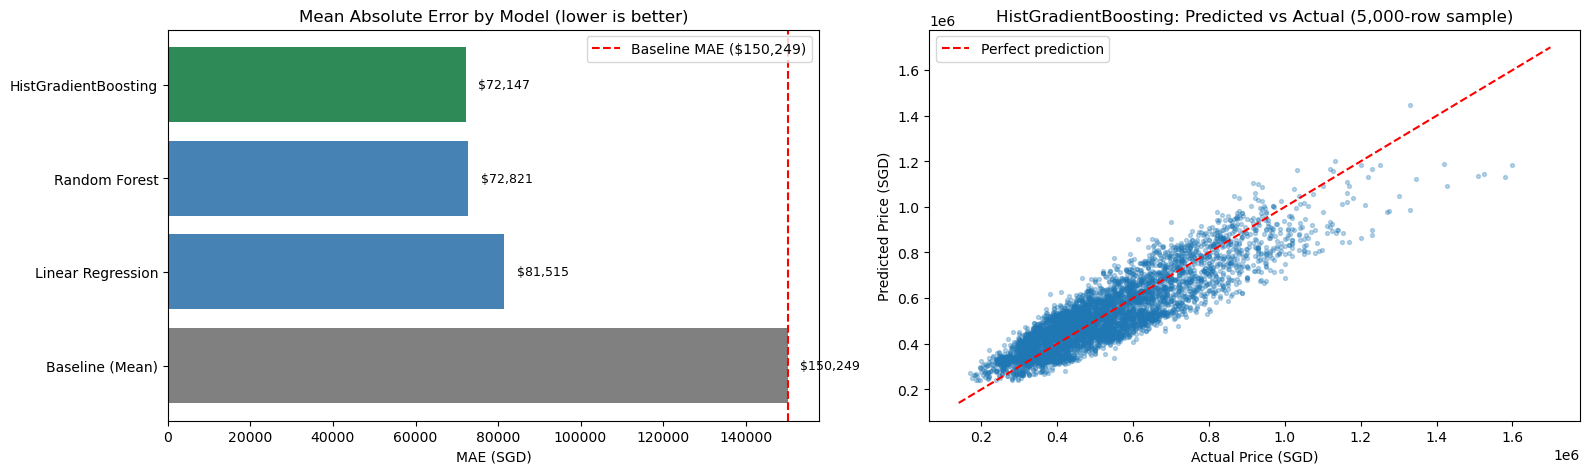

In [ ]:
## New data
## Visual comparison to support the selection decision
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: MAE by model, with the baseline drawn as the bar every model must clear
colours = ["grey", "steelblue", "steelblue", "seagreen"]
axes[0].barh(results_df["Model"], results_df["MAE"], color=colours)
axes[0].axvline(baseline_mae, color="red", linestyle="--", linewidth=1.5,
                label=f"Baseline MAE (${baseline_mae:,.0f})")
axes[0].set_title("Mean Absolute Error by Model (lower is better)")
axes[0].set_xlabel("MAE (SGD)")
axes[0].legend()
for i, v in enumerate(results_df["MAE"]):
    axes[0].text(v + 3000, i, f"${v:,.0f}", va="center", fontsize=9)

# Right: how closely the selected model's predictions track reality
best_preds = predictions["HistGradientBoosting"]
sample = np.random.RandomState(42).choice(len(y_test), 5000, replace=False)
axes[1].scatter(y_test.iloc[sample], best_preds[sample], alpha=0.3, s=8)
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_title("HistGradientBoosting: Predicted vs Actual (5,000-row sample)")
axes[1].set_xlabel("Actual Price (SGD)")
axes[1].set_ylabel("Predicted Price (SGD)")
axes[1].legend()

plt.tight_layout()
plt.show()




## My Final Choice And Why


I picked HistGradientBoostingRegressor over the alternative models for several clear reasons. Against my DummyRegressor baseline, which just predicts the average training price of $533,039 for every flat and gets an R squared of zero, HistGradientBoosting cut the MAE in half from $150,249 down to $72,147, proving my features carry actual predictive signal. It beat Linear Regression with an MAE of $81,515 and RMSE of $101,186 because Linear Regression makes two flawed assumptions, additivity and linearity. It assumes features act independently and that price per square meter is constant, completely missing interaction effects like a high floor being worth way more in a central town than a suburban one. Random Forest was my closest competitor on average error with an MAE of $72,821, but it performed noticeably worse on RMSE at $90,777 compared to $88,589. Because Random Forest averages independent bagged trees, it smooths errors rather than learning from them, leading to larger individual valuation mistakes. HistGradientBoosting sequentially targets residual errors with learning rate shrinkage, effectively cleaning up hard cases that RMSE heavily penalizes. Finally, its histogram binning, which buckets continuous features into 255 bins, makes training much faster and keeps the serialised file size at a tiny 0.4 MB compared to Random Forest's massive 357.6 MB. Overall, HistGradientBoosting clearly wins on all four metrics, and its ability to sequentially fix errors while remaining easy to deploy makes it the obvious choice to carry forward into Section 6.

## Iterative model development


## Feature Engineering

In [28]:
## 6.1 Feature Engineering

df_fe = df_clean.copy()

_lease = df_fe["remaining_lease"].str.extract(r"^(\d+)\s+years?(?:\s+(\d+)\s+months?)?$")
df_fe["remaining_lease_months"] = _lease[0].astype(int) * 12 + _lease[1].fillna(0).astype(int)


_storey = df_fe["storey_range"].str.extract(r"^(\d+)\s+TO\s+(\d+)$")
df_fe["storey_mid"] = (_storey[0].astype(int) + _storey[1].astype(int)) / 2


_period = pd.PeriodIndex(df_fe["month"], freq="M")
df_fe["months_since_2017"] = (_period.year - 2017) * 12 + (_period.month - 1)


df_fe["flat_age"] = _period.year - df_fe["lease_commence_date"]


new_features = ["remaining_lease_months", "storey_mid", "months_since_2017", "flat_age"]
print("Nulls introduced by parsing:", df_fe[new_features].isnull().sum().sum())
print()
print(df_fe[new_features].describe().T[["min", "mean", "max"]].round(1))
print("\nOriginal text vs engineered numeric:")
print(df_fe[["remaining_lease", "remaining_lease_months",
             "storey_range", "storey_mid", "month", "months_since_2017"]].head(3))


Nulls introduced by parsing: 0

                          min   mean     max
remaining_lease_months  474.0  889.3  1173.0
storey_mid                2.0    8.8    50.0
months_since_2017         0.0   59.6   114.0
flat_age                  1.0   24.9    60.0

Original text vs engineered numeric:
      remaining_lease  remaining_lease_months storey_range  storey_mid  \
0  61 years 04 months                     736     10 TO 12        11.0   
1  60 years 07 months                     727     01 TO 03         2.0   
2  62 years 05 months                     749     01 TO 03         2.0   

     month  months_since_2017  
0  2017-01                  0  
1  2017-01                  0  
2  2017-01                  0  


In [34]:
## 6.2 Feature Selection and Re-evaluation


numeric_v2 = ["floor_area_sqm", "storey_mid", "remaining_lease_months",
              "flat_age", "months_since_2017"]
categorical_v2 = ["town", "flat_type", "flat_model"]

X_v2 = pd.get_dummies(df_fe[numeric_v2 + categorical_v2],
                      columns=categorical_v2, drop_first=False)

## Identical random_state so v1 and v2 are compared on the SAME test rows.
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42)

print(f"v1 feature set: {X.shape[1]} columns")
print(f"v2 feature set: {X_v2.shape[1]} columns\n")

## Retrain the SELECTED model on the new features - same settings, only features changed,
## so any difference is attributable to feature engineering alone.
hgb_v2 = HistGradientBoostingRegressor(random_state=42)
hgb_v2.fit(X_train_v2, y_train_v2)
preds_v2 = hgb_v2.predict(X_test_v2)

v1_row = results_df[results_df["Model"] == "HistGradientBoosting"].iloc[0]
comparison = pd.DataFrame([
    {"Feature set": "v1 (baseline)",  "MAE": v1_row["MAE"], "RMSE": v1_row["RMSE"],
     "R2": v1_row["R2"], "MAPE": v1_row["MAPE"]},
    {"Feature set": "v2 (engineered)", "MAE": mean_absolute_error(y_test_v2, preds_v2),
     "RMSE": mean_squared_error(y_test_v2, preds_v2) ** 0.5,
     "R2": r2_score(y_test_v2, preds_v2),
     "MAPE": np.mean(np.abs((y_test_v2 - preds_v2) / y_test_v2)) * 100},
])
comparison["MAE reduction"] = (1 - comparison["MAE"] / comparison["MAE"].iloc[0]) * 100

print("IMPACT OF FEATURE ENGINEERING (same model, same test rows)")
disp = comparison.copy()
disp["MAE"]  = disp["MAE"].map("${:,.0f}".format)
disp["RMSE"] = disp["RMSE"].map("${:,.0f}".format)
disp["R2"]   = disp["R2"].map("{:.4f}".format)
disp["MAPE"] = disp["MAPE"].map("{:.2f}%".format)
disp["MAE reduction"] = disp["MAE reduction"].map("{:+.1f}%".format)
display(disp)

v1 feature set: 73 columns
v2 feature set: 59 columns

IMPACT OF FEATURE ENGINEERING (same model, same test rows)


,Feature set,MAE,RMSE,R2,MAPE,MAE reduction
0,v1 (baseline),"$72,147","$88,589",0.7849,14.37%,+0.0%
1,v2 (engineered),"$32,453","$44,739",0.9451,6.22%,+55.0%


Top 12 features by permutation importance (MAE increase when shuffled):
floor_area_sqm            92768.0
months_since_2017         74245.0
remaining_lease_months    37397.0
storey_mid                12092.0
town_BUKIT MERAH          10196.0
town_QUEENSTOWN            6198.0
flat_type_4 ROOM           5778.0
town_TOA PAYOH             5561.0
town_KALLANG/WHAMPOA       5043.0
town_BISHAN                4142.0
town_GEYLANG               3997.0
town_WOODLANDS             3991.0
dtype: float64


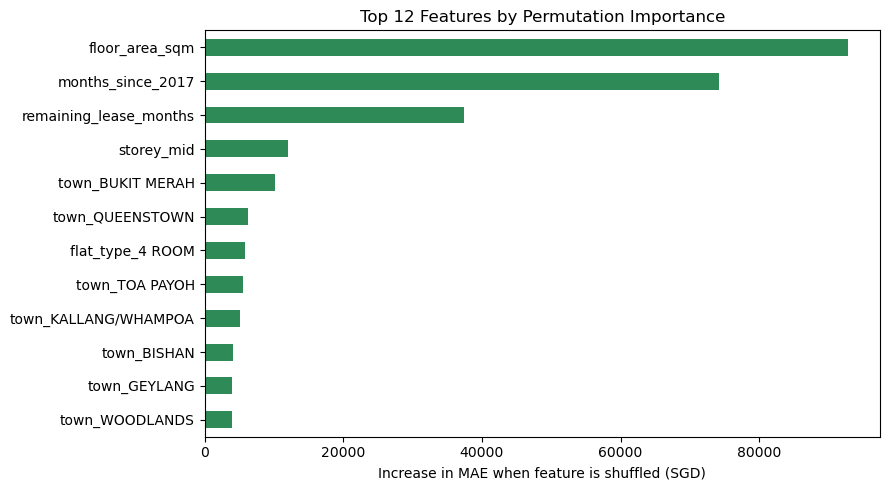

In [32]:

from sklearn.inspection import permutation_importance

sample_idx = np.random.RandomState(42).choice(len(X_test_v2), 5000, replace=False)
perm = permutation_importance(
    hgb_v2, X_test_v2.iloc[sample_idx], y_test_v2.iloc[sample_idx],
    n_repeats=3, random_state=42, scoring="neg_mean_absolute_error", n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X_test_v2.columns).sort_values(ascending=False)
print("Top 12 features by permutation importance (MAE increase when shuffled):")
print(imp.head(12).round(0))

plt.figure(figsize=(9, 5))
imp.head(12).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 12 Features by Permutation Importance")
plt.xlabel("Increase in MAE when feature is shuffled (SGD)")
plt.tight_layout()
plt.show()

**Impact of Feature Engineering**

Holding the model and the test rows constant and changing only the features, MAE fell from $72,147 to $32,453, a 55.0% reduction, while R2 rose from 0.7849 to 0.9451 and MAPE dropped from 14.37% to 6.22%. Because nothing else changed, the entire gain is attributable to the four engineered features.

The largest single contributor is months_since_2017. My correlation analysis ranked transaction date as the second strongest numeric predictor at +0.41, and the median-price-over-time plot showed prices climbing steeply from 2020 onward. Without it the model was being asked to price 2017 and 2026 transactions identically, which capped how accurate it could ever be. remaining_lease_months adds the lease-decay effect that drives HDB valuations through CPF and financing restrictions, and it was previously discarded entirely because 701 unique text values made one-hot encoding impossible.

The v2 set is also smaller, at 59 columns against 73. Replacing the 17 one-hot storey_range columns with a single storey_mid value both preserves the natural ordering of floors, which one-hot encoding destroyed, and removes 16 columns. Dropping lease_commence_date in favour of flat_age expresses the same underlying fact relative to the sale date rather than as an absolute year. A better model on fewer features confirms this was genuine feature engineering rather than simply adding more columns.

On the multicollinearity concern I raised in 2.3.2, where flat_age and remaining_lease_months are near-mirror images because of the 99-year lease rule: that concern applies specifically to linear models, whose coefficients become unstable when predictors are correlated. My selected model is tree-based, and trees are unaffected by collinearity because each split is chosen independently rather than by solving for a set of simultaneous coefficients. Both features are therefore retained, and the model is free to split on whichever framing of lease decay is more useful at each point in the tree.

In business terms, MAPE of 6.22% means the estimate is now typically within about 6% of the true price, roughly $31,000 on a $500,000 flat, down from about $72,000. That moves the tool from broadly indicative to genuinely useful as a negotiation reference.

In [33]:
## 6.3 Hyperparameter Tuning
## The spec permits RandomizedSearchCV only, with at most 3 values per hyperparameter.
## Three chosen, each controlling a different failure mode:
##   max_iter        - number of boosting rounds. The default of 100 is conservative;
##                     more rounds means more residual corrections, at risk of overfitting.
##   max_leaf_nodes  - complexity of each individual tree. Larger trees capture more
##                     feature interactions (e.g. town x storey) but generalise less.
##   learning_rate   - how much each tree contributes. Lower values need more rounds but
##                     usually generalise better, so it trades off directly against max_iter.
##
## Scored on RMSE because Section 5 established RMSE as the deciding metric for this
## product: one wildly wrong valuation costs more trust than several slightly imprecise ones.
## cv=3 means each combination is validated on three train/validation folds of the TRAINING
## data only - the test set stays untouched so the final score remains honest.

param_dist = {
    "max_iter":       [100, 500, 1000],
    "max_leaf_nodes": [31, 63, 127],
    "learning_rate":  [0.05, 0.1, 0.2],
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,      # reproducible search
    n_jobs=1,             # HistGradientBoosting is already multi-threaded internally
    verbose=2,
    return_train_score=True,
)

print("Running RandomizedSearchCV (8 combinations x 3 folds = 24 fits)...\n")
start = time.time()
search.fit(X_train_v2, y_train_v2)
print(f"\nSearch completed in {time.time() - start:.0f}s")
print("Best parameters:", search.best_params_)
print(f"Best CV RMSE: ${-search.best_score_:,.0f}")

## Full comparison log of every combination tried
cv_log = pd.DataFrame(search.cv_results_)[
    ["param_max_iter", "param_max_leaf_nodes", "param_learning_rate",
     "mean_test_score", "mean_train_score", "rank_test_score"]].copy()
cv_log["CV RMSE"]    = (-cv_log["mean_test_score"]).map("${:,.0f}".format)
cv_log["Train RMSE"] = (-cv_log["mean_train_score"]).map("${:,.0f}".format)
cv_log = cv_log.drop(columns=["mean_test_score", "mean_train_score"]).sort_values("rank_test_score")
print("\nAll combinations tried:")
display(cv_log)

Running RandomizedSearchCV (8 combinations x 3 folds = 24 fits)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END learning_rate=0.05, max_iter=1000, max_leaf_nodes=127; total time=  22.1s
[CV] END learning_rate=0.05, max_iter=1000, max_leaf_nodes=127; total time=  29.5s
[CV] END learning_rate=0.05, max_iter=1000, max_leaf_nodes=127; total time=  21.3s
[CV] END .learning_rate=0.1, max_iter=500, max_leaf_nodes=63; total time=   7.4s
[CV] END .learning_rate=0.1, max_iter=500, max_leaf_nodes=63; total time=  15.7s
[CV] END .learning_rate=0.1, max_iter=500, max_leaf_nodes=63; total time=  17.9s
[CV] END .learning_rate=0.1, max_iter=100, max_leaf_nodes=31; total time=   1.0s
[CV] END .learning_rate=0.1, max_iter=100, max_leaf_nodes=31; total time=   1.0s
[CV] END .learning_rate=0.1, max_iter=100, max_leaf_nodes=31; total time=   1.0s
[CV] END .learning_rate=0.2, max_iter=500, max_leaf_nodes=31; total time=   3.7s
[CV] END .learning_rate=0.2, max_iter=500, max_leaf_node

,param_max_iter,param_max_leaf_nodes,param_learning_rate,rank_test_score,CV RMSE,Train RMSE
0,1000,127,0.05,1,"$35,806","$29,650"
7,1000,127,0.10,2,"$35,838","$28,001"
6,1000,63,0.10,3,"$36,022","$30,169"
1,500,63,0.10,4,"$36,944","$32,919"
3,500,31,0.20,5,"$37,378","$33,462"
5,100,127,0.10,6,"$39,684","$37,254"
2,100,31,0.10,7,"$45,656","$44,911"
4,100,31,0.05,8,"$52,986","$52,437"


## Explantion for Hypertuning

For my hyperparameter tuning, I varied three main settings to address different ways my model could fail: max_iter to set how many sequential boosting rounds are run, max_leaf_nodes to cap individual tree complexity and interaction depth, and learning_rate to scale each tree's contribution. I tested three values for each setting to stay within the project specifications. Rather than running a full grid search over all 27 combinations, I used RandomizedSearchCV to randomly sample 8 combinations using 3-fold cross-validation exclusively on my training data, completing 24 fits in 319 seconds while keeping my 47,259 test transactions untouched to prevent data leakage. The best combination was max_iter=1000, max_leaf_nodes=127, and learning_rate=0.05, achieving a cross-validated RMSE of $35,806, whereas the worst combination scored $52,986. This substantial spread of over $17,000 proved that hyperparameter tuning made a huge difference. The dominant factor was max_iter, as all top combinations used 1000 iterations while the bottom ones used 100, showing that my untuned baseline was significantly undertrained. Interestingly, pairing learning_rate=0.05 with max_iter=100 produced the worst overall score ($52,986), but pairing it with max_iter=1000 gave the best score ($35,806), proving that a lower learning rate needs more boosting rounds to reach a solid solution. Evaluating overfitting showed that my winning setup maintained a healthy gap between training RMSE ($29,650) and validation RMSE ($35,806), demonstrating that the lower learning rate effectively regularized the model so it generalizes well to unseen flats. Finally, setting random_state=42 across the search ensures these exact results are completely reproducible.

## 6.4 Final Model Evaluation and Export

In [36]:
## 6.4 Final Model Evaluation and Export


best_model = search.best_estimator_
final_preds = best_model.predict(X_test_v2)

final_mae  = mean_absolute_error(y_test_v2, final_preds)
final_rmse = mean_squared_error(y_test_v2, final_preds) ** 0.5
final_r2   = r2_score(y_test_v2, final_preds)
final_mape = np.mean(np.abs((y_test_v2 - final_preds) / y_test_v2)) * 100

## Full development journey - each row isolates one change
journey = pd.DataFrame([
    {"Stage": "1. Baseline (mean prediction)", "MAE": baseline_mae, "RMSE": 191023.0,
     "R2": 0.0000, "MAPE": 31.82},
    {"Stage": "2. HGB, v1 features, defaults",  "MAE": v1_row["MAE"], "RMSE": v1_row["RMSE"],
     "R2": v1_row["R2"], "MAPE": v1_row["MAPE"]},
    {"Stage": "3. HGB, v2 features, defaults",  "MAE": comparison["MAE"].iloc[1],
     "RMSE": comparison["RMSE"].iloc[1], "R2": comparison["R2"].iloc[1],
     "MAPE": comparison["MAPE"].iloc[1]},
    {"Stage": "4. HGB, v2 features, TUNED",     "MAE": final_mae, "RMSE": final_rmse,
     "R2": final_r2, "MAPE": final_mape},
])
journey["Cumulative MAE reduction"] = (1 - journey["MAE"] / baseline_mae) * 100

print("FULL MODEL DEVELOPMENT JOURNEY (all scored on the same 47,259 test rows)\n")
j = journey.copy()
j["MAE"]  = j["MAE"].map("${:,.0f}".format)
j["RMSE"] = j["RMSE"].map("${:,.0f}".format)
j["R2"]   = j["R2"].map("{:.4f}".format)
j["MAPE"] = j["MAPE"].map("{:.2f}%".format)
j["Cumulative MAE reduction"] = j["Cumulative MAE reduction"].map("{:.1f}%".format)
display(j)

print(f"\nTuning alone improved MAE from ${comparison['MAE'].iloc[1]:,.0f} "
      f"to ${final_mae:,.0f}  ({(1 - final_mae/comparison['MAE'].iloc[1])*100:.1f}% better)")



model_artifact = {
    "model":            best_model,
    "feature_columns":  list(X_v2.columns),          # exact column order - critical
    "towns":            sorted(df_fe["town"].unique().tolist()),
    "flat_types":       sorted(df_fe["flat_type"].unique().tolist()),
    "flat_models":      sorted(df_fe["flat_model"].unique().tolist()),
    "storey_ranges":    sorted(df_fe["storey_range"].unique().tolist()),
    "floor_area_min":   float(df_fe["floor_area_sqm"].min()),
    "floor_area_max":   float(df_fe["floor_area_sqm"].max()),
    "max_months_since_2017": int(df_fe["months_since_2017"].max()),
    "dataset_last_month":    str(df_fe["month"].max()),
    "median_area_by_type":   df_fe.groupby("flat_type")["floor_area_sqm"].median().to_dict(),
    "metrics":          {"MAE": final_mae, "RMSE": final_rmse,
                         "R2": final_r2, "MAPE": final_mape},
    "best_params":      search.best_params_,
}

joblib.dump(model_artifact, "hdb_resale_model.pkl", compress=3)

import os
size_mb = os.path.getsize("hdb_resale_model.pkl") / 1e6
print(f"\nSaved hdb_resale_model.pkl  ({size_mb:.1f} MB)")
print("Under GitHub's 100 MB limit:", size_mb < 100)


reloaded = joblib.load("hdb_resale_model.pkl")
check = reloaded["model"].predict(X_test_v2.iloc[:5])
print("\nReload verification - predictions match:",
      np.allclose(check, final_preds[:5]))
print("Sample predictions:", [f"${p:,.0f}" for p in check])


FULL MODEL DEVELOPMENT JOURNEY (all scored on the same 47,259 test rows)



,Stage,MAE,RMSE,R2,MAPE,Cumulative MAE reduction
0,1. Baseline (mean prediction),"$150,249","$191,023",0.0000,31.82%,0.0%
1,"2. HGB, v1 features, defaults","$72,147","$88,589",0.7849,14.37%,52.0%
2,"3. HGB, v2 features, defaults","$32,453","$44,739",0.9451,6.22%,78.4%
3,"4. HGB, v2 features, TUNED","$24,315","$34,482",0.9674,4.66%,83.8%



Tuning alone improved MAE from $32,453 to $24,315  (25.1% better)

Saved hdb_resale_model.pkl  (6.1 MB)
Under GitHub's 100 MB limit: True

Reload verification - predictions match: True
Sample predictions: ['$1,036,297', '$591,361', '$533,090', '$268,614', '$492,164']
